# 03 - Random Forest

Non linear, tree based ensemble - captures interaction effects without hand engineering them, plus global feature importances.


## Setup

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
import joblib

train_df = pd.read_csv(Path('../../../data/processed/model_ready_train.csv'))
val_df = pd.read_csv(Path('../../../data/processed/model_ready_val.csv'))

bool_cols = train_df.select_dtypes(include='bool').columns
train_df[bool_cols] = train_df[bool_cols].astype(int)
val_df[bool_cols] = val_df[bool_cols].astype(int)

X_train = train_df.drop(columns=['Late_delivery_risk'])
y_train = train_df['Late_delivery_risk']
X_val = val_df.drop(columns=['Late_delivery_risk'])
y_val = val_df['Late_delivery_risk']


## 1. Train 

In [3]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_val)
y_score = rf.predict_proba(X_val)[:, 1]


## 2. Evaluate on the validation set

In [4]:
from sklearn.metrics import (recall_score, precision_score, f1_score,
                              roc_auc_score, average_precision_score,
                              confusion_matrix, classification_report,
                              roc_curve, precision_recall_curve)
import json
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_and_plot(y_true, y_pred, y_score, model_name, save_prefix=None):
    metrics = {
        'model': model_name,
        'recall': recall_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'roc_auc': roc_auc_score(y_true, y_score),
        'pr_auc': average_precision_score(y_true, y_score),
    }
    print(f"--- {model_name} (validation set) ---")
    for k, v in metrics.items():
        if k != 'model':
            print(f"  {k}: {v:.4f}")
    print()
    print(classification_report(y_true, y_pred, target_names=['On time (0)', 'Late (1)']))

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['On time', 'Late'], yticklabels=['On time', 'Late'])
    axes[0].set_title(f'{model_name} — Confusion Matrix')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')

    fpr, tpr, _ = roc_curve(y_true, y_score)
    axes[1].plot(fpr, tpr, label=f"AUC = {metrics['roc_auc']:.3f}", color='#4C72B0', linewidth=2)
    axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
    axes[1].set_title(f'{model_name} — ROC Curve')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].legend(loc='lower right')

    prec, rec, _ = precision_recall_curve(y_true, y_score)
    axes[2].plot(rec, prec, label=f"PR-AUC = {metrics['pr_auc']:.3f}", color='#C44E52', linewidth=2)
    axes[2].set_title(f'{model_name} — Precision-Recall Curve')
    axes[2].set_xlabel('Recall')
    axes[2].set_ylabel('Precision')
    axes[2].legend(loc='lower left')

    plt.tight_layout()
    if save_prefix:
        plt.savefig(f'../../../reports/figures/{save_prefix}_evaluation.png', dpi=120, bbox_inches='tight')
    plt.show()

    return metrics

def save_metrics(metrics, path):
    with open(path, 'w') as f:
        json.dump(metrics, f, indent=2)
    print(f"Saved metrics to {path}")


--- Random Forest (validation set) ---
  recall: 0.6172
  precision: 0.7924
  f1: 0.6939
  roc_auc: 0.7580
  pr_auc: 0.8234

              precision    recall  f1-score   support

 On time (0)       0.64      0.81      0.71      3611
    Late (1)       0.79      0.62      0.69      4279

    accuracy                           0.70      7890
   macro avg       0.72      0.71      0.70      7890
weighted avg       0.72      0.70      0.70      7890



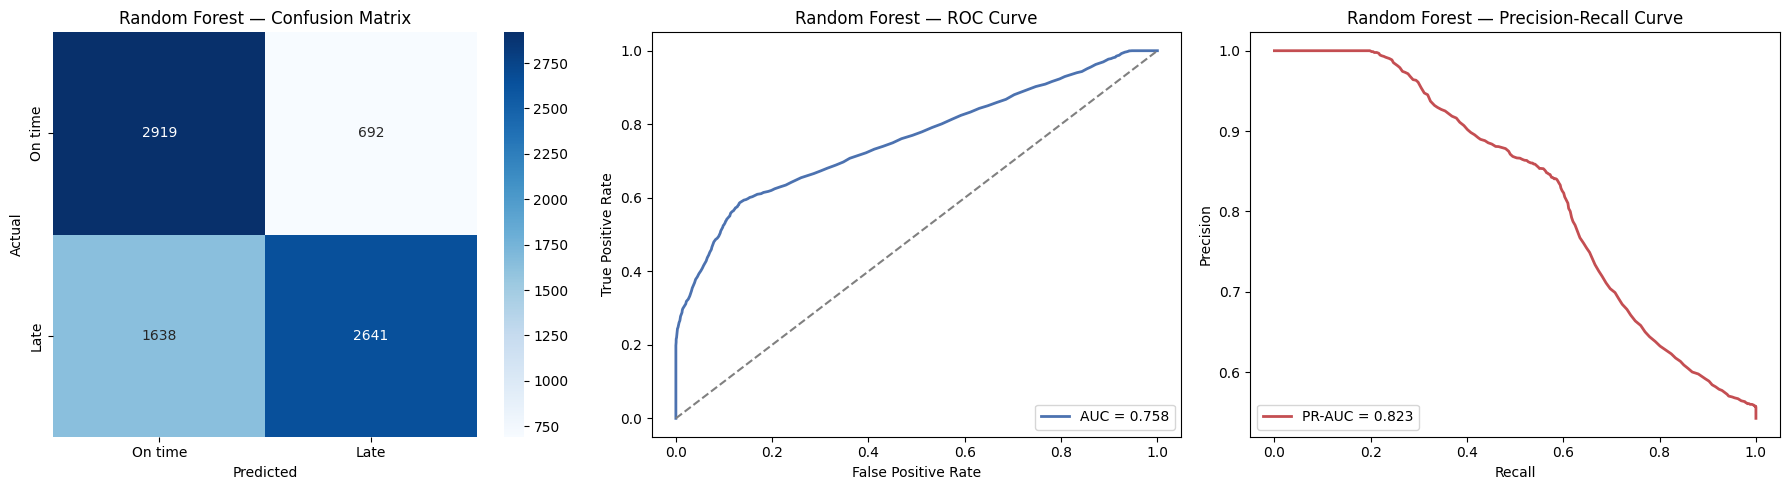

In [5]:
rf_metrics = evaluate_and_plot(y_val, y_pred, y_score, 'Random Forest', save_prefix='random_forest')


**What we found:**

**A real, meaningful jump in Recall, the metric that matters most for this project, at the cost of some Precision:**

| Metric | Baseline | Logistic Regression | Random Forest |
|---|---|---|---|
| Recall | 0.5349 | 0.5543 | **0.6172** |
| Precision | 0.8391 | 0.8379 | 0.7924 |
| F1 | 0.6533 | 0.6672 | **0.6939** |
| ROC-AUC | 0.7270 | 0.7394 | **0.7580** |
| PR-AUC | 0.7429 | 0.8105 | **0.8234** |

Random Forest catches noticeably more actual late deliveries than either the baseline or Logistic Regression (Recall up 6 to 8 points), at a real but proportionate cost in Precision (down about 4.5 points). Since Recall is our primary metric precisely because a missed late delivery costs more than a false alarm, this is a good tradeoff for our stated business priority, not just a raw-numbers win. F1, ROC-AUC, and PR-AUC all improved too, confirming this isn't just a threshold artifact, Random Forest is genuinely ranking and separating the two classes better than the linear model.


## 3. Feature importances

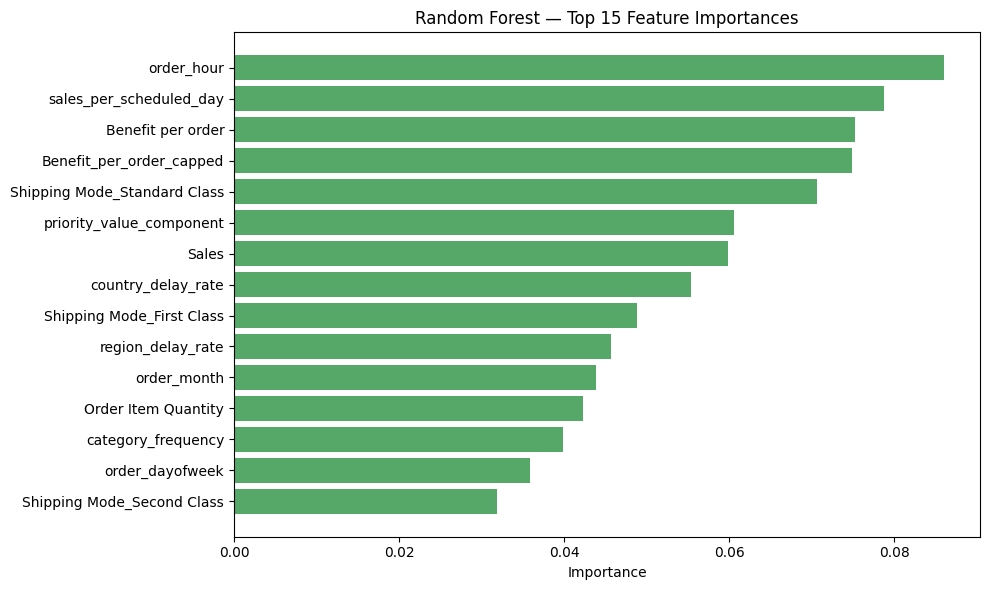

In [6]:
import matplotlib.pyplot as plt

importance_df = pd.DataFrame({'feature': X_train.columns, 'importance': rf.feature_importances_})
importance_df = importance_df.sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'], importance_df['importance'], color='#55A868')
plt.xlabel('Importance')
plt.title('Random Forest — Top 15 Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../../../reports/figures/rf_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()


**What we found: something worth taking seriously before trusting this ranking at face value.**

The importance ranking looks **inconsistent with both EDA and Logistic Regression's coefficients**. `order_hour` comes out as the single most important feature, ahead of everything else, despite the fact that we never even checked `order_hour`'s own predictive spread in EDA (we checked day-of-week, month, weekend, and holiday season, all of which were essentially flat, but not hour specifically). Meanwhile `Shipping Mode`, which dominated both the EDA spread (57pp) and the Logistic Regression coefficients by a wide margin, only shows up around 5th to 9th place here, split awkwardly across its four separate one-hot columns.

**The most likely explanation isn't that order_hour is secretly a powerful predictor, it's a known bias in Random Forest's default importance measure.** `feature_importances_` in scikit-learn uses mean decrease in impurity (MDI), which systematically favors high-cardinality, continuous features (like `order_hour` with 24 possible values, or `sales_per_scheduled_day`, `Benefit per order`, `Sales`) over low-cardinality binary features (like each individual `Shipping Mode_X` one-hot column), simply because continuous features offer far more possible split points for trees to exploit, including spurious ones, inflating their apparent importance without necessarily reflecting real predictive value.

**This doesn't mean Random Forest's predictions are wrong, its actual metrics above are solid.** It means this particular importance chart shouldn't be trusted as-is for the report's interpretability claims. Two honest options: (1) treat this chart as provisional and rely on Stage 8's planned SHAP analysis for the real interpretability story, since SHAP doesn't have this cardinality bias, or (2) compute permutation importance right now as a quick, more trustworthy sanity check. Running the second option below.


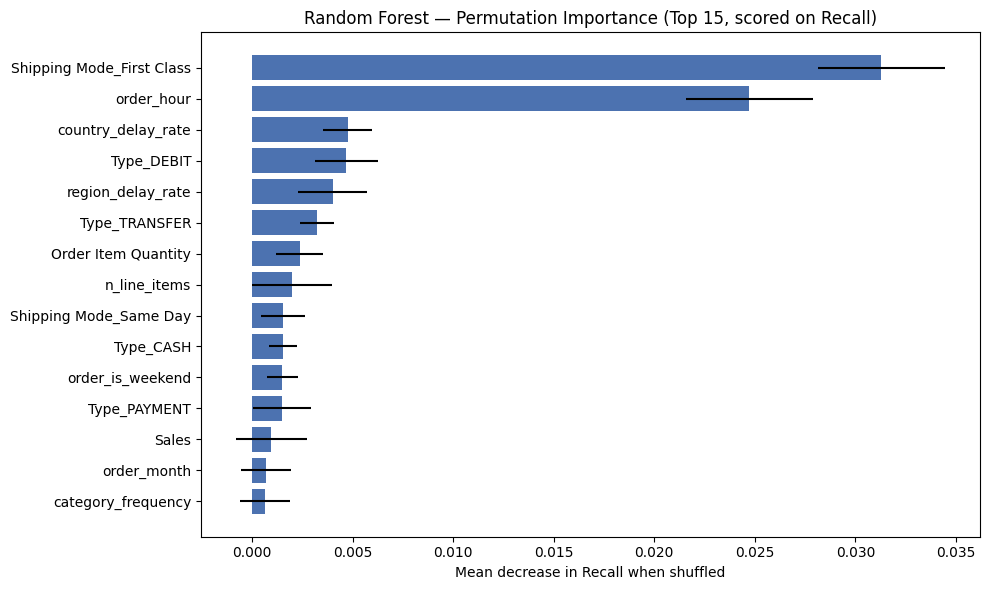

In [7]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(rf, X_val, y_val, n_repeats=10, random_state=42, n_jobs=-1, scoring='recall')

perm_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance_mean': perm_result.importances_mean,
    'importance_std': perm_result.importances_std,
}).sort_values('importance_mean', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(perm_importance_df['feature'], perm_importance_df['importance_mean'],
          xerr=perm_importance_df['importance_std'], color='#4C72B0')
plt.xlabel('Mean decrease in Recall when shuffled')
plt.title('Random Forest — Permutation Importance (Top 15, scored on Recall)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../../../reports/figures/rf_permutation_importance.png', dpi=120, bbox_inches='tight')
plt.show()


**What we found:**

**Partially confirms the bias, but with a genuine surprise attached.** `Shipping Mode_First Class` does reclaim the top spot once corrected for the cardinality bias (0.031 mean decrease in Recall when shuffled), exactly as expected, this confirms the earlier MDI chart understated Shipping Mode's real importance.

**But `order_hour` still ranks second, well ahead of everything else including the geographic delay rates**, and its error bar doesn't overlap zero, this isn't just noise from the correction. That's a genuine surprise worth taking seriously rather than dismissing: EDA's univariate check found hour-of-day patterns essentially flat on their own, and permutation importance is now saying `order_hour` matters a real amount to the model's predictions.

**The likely explanation, and it's actually a good one:** permutation importance measures a feature's contribution *within the full model*, including any interaction effects with other features, not just its standalone relationship with the target the way a simple EDA groupby does. It's plausible that `order_hour` doesn't predict lateness on its own, but *combined* with Shipping Mode or region (e.g. orders placed at certain hours on certain shipping modes behaving differently), it carries real signal a univariate check would never surface. This is actually a good example of exactly why tree ensembles are useful, they can capture interactions a linear model or a simple bivariate EDA pass can't.

**Worth a follow up before fully trusting this, though, rather than taking it at face value:** a quick bivariate check (e.g. late rate grouped by `order_hour` × `Shipping Mode` on the training data) would confirm whether this is a real interaction effect or still some artifact worth investigating further. This is a good candidate for a short SHAP dependence plot investigation in Stage 8, SHAP can directly show whether `order_hour`'s effect on predictions actually depends on another feature's value, which would confirm or rule out the interaction-effect explanation properly.

**Bottom line:** Shipping Mode remains the dominant single signal, consistent with EDA and Logistic Regression throughout. `order_hour`'s importance is not simply an MDI artifact, since it survives the bias correction, but its exact role (standalone vs. interaction driven) is worth a follow up check in Stage 8 rather than asserted outright here.


## 4. Save model and metrics

In [8]:
joblib.dump(rf, '../../../models/random_forest.pkl')
save_metrics(rf_metrics, '../../../data/processed/metrics_rf.json')


Saved metrics to ../../../data/processed/metrics_rf.json
